In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # "Programming Part" auf sys.path

from env import gymnasium_env as drausp_env
import numpy as np

from env.instance_reader import get_instance_data
import matplotlib.pyplot as plt

data_path = Path("../../instances/lion18s/SA01.txt")

In [2]:
DRAUSP_data = get_instance_data(data_path)

K = DRAUSP_data.num_slots
T_d = DRAUSP_data.num_requests
C_k = DRAUSP_data.capacity_vector
instance = DRAUSP_data.instance
request_lengths = DRAUSP_data.request_length
print(K)
print(T_d)
print(C_k)
print(instance)

4
50
[10, 10, 10, 10]
[[41, 1, 1, 0, 0], [39, 1, 1, 0, 0], [20, 1, 3, 0, 0], [61, 2, 1, 0, 0], [18, 2, 1, 0, 0], [23, 1, 4, 0, 0], [25, 1, 1, 0, 0], [13, 1, 1, 0, 0], [77, 1, 1, 0, 0], [8, 1, 2, 0, 0], [25, 1, 3, 0, 0], [74, 1, 1, 0, 0], [39, 1, 3, 0, 0], [54, 3, 2, 0, 0], [70, 1, 3, 0, 0], [71, 1, 1, 0, 0], [55, 1, 1, 0, 0], [9, 1, 1, 0, 0], [96, 1, 1, 0, 0], [63, 3, 2, 0, 0], [50, 3, 2, 0, 0], [20, 1, 1, 0, 0], [43, 1, 2, 0, 0], [74, 1, 2, 0, 0], [62, 1, 1, 0, 0], [60, 1, 1, 0, 0], [22, 1, 1, 0, 0], [81, 1, 2, 0, 0], [92, 1, 1, 0, 0], [80, 1, 1, 0, 0], [38, 2, 1, 0, 0], [84, 1, 1, 0, 0], [39, 1, 2, 0, 0], [88, 2, 1, 0, 0], [69, 1, 3, 0, 0], [21, 2, 1, 0, 0], [15, 1, 1, 0, 0], [47, 3, 1, 0, 0], [67, 1, 1, 0, 0], [18, 1, 1, 0, 0], [87, 1, 1, 0, 0], [58, 1, 2, 0, 0], [34, 2, 1, 0, 0], [8, 1, 1, 0, 0], [97, 1, 1, 0, 0], [73, 1, 1, 0, 0], [54, 1, 1, 0, 0], [69, 2, 1, 0, 0], [79, 1, 2, 0, 0], [9, 1, 2, 0, 0]]


In [3]:
env = drausp_env.DrauspEnv(K=K, T_d=T_d, C_k=C_k, instance=instance, render_mode="human", fixed_request_length=request_lengths)

## Hier kann getestet werden ob alle Transitions korrekt funktionieren
Mit render bekommt man eine Übersicht was gerade los ist

In [4]:
obs, info = env.reset()
print(obs)
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
env.render()
obs, reward, terminated, truncated, info = env.step(1)
print(terminated)
env.render()

[ 1. 10. 10. 10. 10. 41.  1.  1.  0.  0.]
t=2    Caps=[9, 9, 10, 10]  r=39.00  q=[1, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=3    Caps=[8, 8, 10, 10]  r=20.00  q=[1, 3, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=4    Caps=[7, 5, 10, 10]  r=61.00  q=[2, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=5    Caps=[5, 4, 10, 10]  r=18.00  q=[2, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
t=6    Caps=[3, 3, 10, 10]  r=23.00  q=[1, 4, 0, 0]  Valid Actions: [0, 2, 3]
True
t=7    Caps=[2, -1, 10, 10]  r=25.00  q=[1, 1, 0, 0]  Valid Actions: [0, 3]


In [5]:
from training.dqn_agent import DQNAgent
from models.standard_dqn import DQNNetwork
agent = DQNAgent(env, QnetworkClass=DQNNetwork, monotonicity_penalty=True, reject_bias = 0.75, gamma = 0.98, epsilon_decay_steps=10000)

In [6]:
reward_history, monotonicity_violations, depth_history = agent.train(num_episodes=1500)

  Systematic monotonicity (Episode 1): C_k: 50.5%, t: 49.0%, r: 36.0%, q: 68.5%, mixed: 40.6%
Episode   50/1500  Reward:   436.00  Avg(50):   541.68  Tiefe:   23  Avg-Tiefe(50):   36.2  ε: 0.851
  Systematic monotonicity (Episode 51): C_k: 100.0%, t: 0.0%, r: 84.5%, q: 0.0%, mixed: 100.0%
Episode  100/1500  Reward:   453.00  Avg(50):   550.12  Tiefe:   24  Avg-Tiefe(50):   29.8  ε: 0.747
  Systematic monotonicity (Episode 101): C_k: 100.0%, t: 8.7%, r: 79.5%, q: 8.0%, mixed: 100.0%
Episode  150/1500  Reward:   481.00  Avg(50):   532.40  Tiefe:   41  Avg-Tiefe(50):   26.4  ε: 0.667
  Systematic monotonicity (Episode 151): C_k: 100.0%, t: 9.7%, r: 77.0%, q: 23.5%, mixed: 100.0%
Episode  200/1500  Reward:   278.00  Avg(50):   532.60  Tiefe:   14  Avg-Tiefe(50):   24.1  ε: 0.603
  Systematic monotonicity (Episode 201): C_k: 100.0%, t: 7.7%, r: 79.5%, q: 35.0%, mixed: 100.0%
Episode  250/1500  Reward:   730.00  Avg(50):   559.72  Tiefe:   26  Avg-Tiefe(50):   25.7  ε: 0.542
  Systematic mon

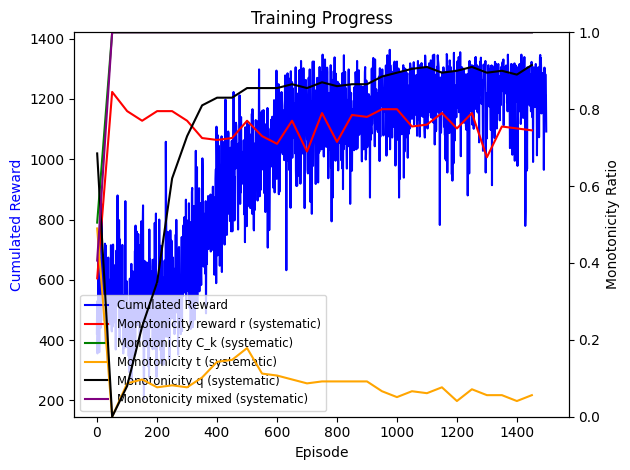

In [7]:
from training.plotting import plot_training_progress, plot_depth_epsilon

plot_training_progress(reward_history, monotonicity_violations)

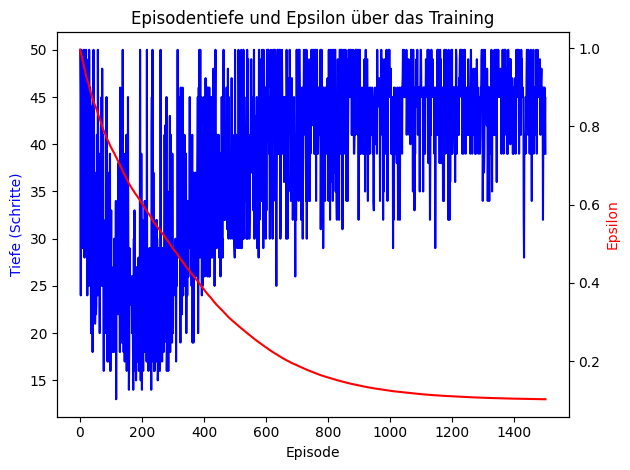

In [8]:
plot_depth_epsilon(depth_history)

## Beispiel-Durchlauf des trainierten Agenten

In [9]:
agent.epsilon = 0.0  # rein exploitativ, keine Exploration

obs, info = env.reset()
done = False
total_reward = 0.0

while not done:
    action = agent.select_action(obs)
    print(f"Aktion gewählt: {action}")
    obs, reward, terminated, truncated, info = env.step(action)
    env.render()
    total_reward += reward
    done = terminated or truncated

print(f"\nGesamtreward (greedy Durchlauf): {total_reward:.2f}")

Aktion gewählt: 3
t=2    Caps=[10, 10, 9, 9]  r=39.00  q=[1, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 3
t=3    Caps=[10, 10, 8, 8]  r=20.00  q=[1, 3, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 0
t=4    Caps=[10, 10, 8, 8]  r=61.00  q=[2, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 1
t=5    Caps=[8, 9, 8, 8]  r=18.00  q=[2, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 0
t=6    Caps=[8, 9, 8, 8]  r=23.00  q=[1, 4, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 0
t=7    Caps=[8, 9, 8, 8]  r=25.00  q=[1, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 0
t=8    Caps=[8, 9, 8, 8]  r=13.00  q=[1, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 0
t=9    Caps=[8, 9, 8, 8]  r=77.00  q=[1, 1, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 3
t=10   Caps=[8, 9, 7, 7]  r=8.00  q=[1, 2, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 0
t=11   Caps=[8, 9, 7, 7]  r=25.00  q=[1, 3, 0, 0]  Valid Actions: [0, 1, 2, 3]
Aktion gewählt: 0
t=12   